In [915]:
import h5py as h5
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [916]:
# data_dict['K562'] = h5py.File(self.data_folder + '/K562_DNase_ENCFF257HEE_2kb_4DNFITUOMFUQ_enhancer_promoter_encoding.h5', 'r')
# self.data_dict['GM12878'] = h5py.File(self.data_folder + '/GM12878_DNase_ENCFF020WZB_2kb_4DNFI1UEG1HD_promoter_enhancer_encoding.h5', 'r')
data_h5 = h5.File('../data/K562_DNase_ENCFF257HEE_2kb_4DNFITUOMFUQ_enhancer_promoter_encoding.h5', 'r')
created_ge_links = pd.read_csv('../data/K562_gene_enhancer_links.csv')

In [917]:
data_h5.keys()

<KeysViewHDF5 ['activity', 'distance', 'ensid', 'hic', 'pe_code']>

In [918]:
# find index where ensid is ENSG00000187905
idx = np.where(data_h5['ensid'][:] == b'ENSG00000000419')[0][0]
idx

2

In [919]:
idx = 125
sample_ensid = data_h5['ensid'][idx].decode()
sample_ensid

'ENSG00000006194'

In [920]:
data_h5['pe_code'][idx].shape

(61, 2000, 4)

In [921]:
enhancer_intensity = data_h5['activity'][idx,1:]
enhancer_intensity

array([ 0.460221,  0.434989, 14.969325,  9.977883,  0.716939,  9.433532,
        2.255044,  0.428631,  0.254249,  0.268691,  0.285102,  0.504165,
        2.041125,  4.60416 ,  0.41262 ,  0.276586,  4.431783,  0.808101,
        2.268955,  1.254938,  1.069778,  1.809366,  1.687277,  1.644085,
        0.61628 , 13.133855,  1.522434,  2.10212 , 14.095727,  6.491562,
       12.558895,  0.222269,  1.156094,  6.284852,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ])

In [922]:
data_h5['distance'][idx,1:]

array([  8838.5,  16399. ,  19195.5,  22045.5,  47428. ,  48569.5,
        65356. ,  72737.5,  76053.5,  80523. ,  85151. ,  88557. ,
        91937. ,  94374.5,  95610. , 100000. , 100337. , 102880.5,
       104854. , 105831.5, 106702. , 107939. , 109089. , 111377. ,
       117419. , 117588. , 118736.5, 119986. , 125330. , 131004. ,
       133269. , 143112. , 148366.5, 148519. ,      0. ,      0. ,
            0. ,      0. ,      0. ,      0. ,      0. ,      0. ,
            0. ,      0. ,      0. ,      0. ,      0. ,      0. ,
            0. ,      0. ,      0. ,      0. ,      0. ,      0. ,
            0. ,      0. ,      0. ,      0. ,      0. ,      0. ])

In [923]:
np.min(data_h5['distance'][:,1:])

0.0

In [924]:
enhancer_distance = data_h5['distance'][idx,1:]
enhancer_distance.shape

(60,)

In [925]:
# count how many enhancers are not 0 in the sample and less than 100000
enhancer_intensity[(enhancer_distance > 0) & (enhancer_distance < 100000)].shape[0]

15

Total enhancers: 303813


<Axes: ylabel='Count'>

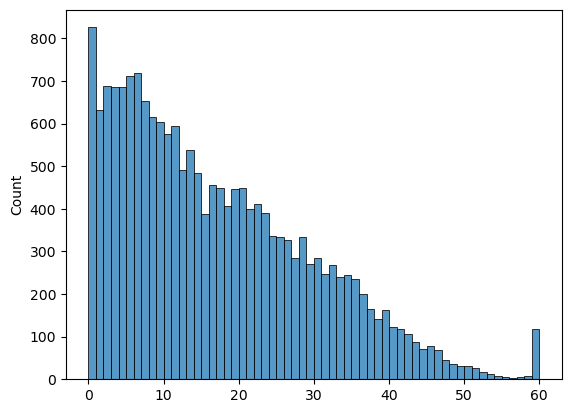

In [926]:
n_enhancers = []
index_max = -1
for idx in range(len(data_h5['ensid'])):
    enhancers = data_h5['distance'][idx,1:]
    n_enhancers.append(enhancers[(enhancers > 0) & (enhancers < 100000)].shape[0])

print(f"Total enhancers: {sum(n_enhancers)}")

sns.histplot(n_enhancers, bins=60)

In [927]:
# get a histogram of the number of enhancers per gene from the created_ge_links dataframe
n_enhancers_ge = []
gene_names = []
for idx in range(len(data_h5['ensid'])):
    sample_ensid = data_h5['ensid'][idx].decode()
    sample_links = created_ge_links[created_ge_links['gene_id'] == sample_ensid]

    n_enhancers_ge.append(len(sample_links))
    gene_names.append(sample_ensid)


In [928]:
for idx, (orig, new, gene_name) in enumerate(zip(n_enhancers, n_enhancers_ge, gene_names)):
    if orig != new:
        print(f"Mismatch: {orig} vs {new} for gene {gene_name} at index {idx}")

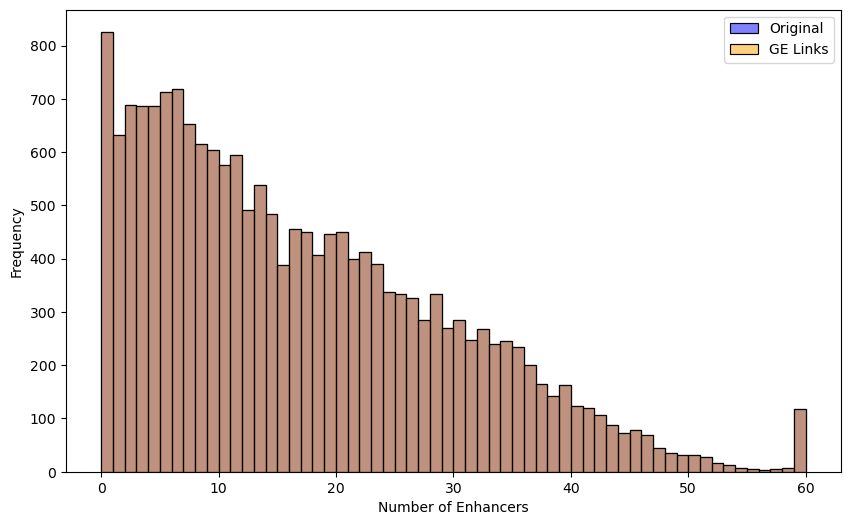

In [929]:
# plot the histogram of the number of enhancers per gene
plt.figure(figsize=(10, 6))
sns.histplot(n_enhancers, bins=60, color='blue', label='Original', alpha=0.5)
sns.histplot(n_enhancers_ge, bins=60, color='orange', label='GE Links', alpha=0.5)
plt.legend()
plt.xlabel('Number of Enhancers')
plt.ylabel('Frequency')
plt.show()

In [930]:
enhancer_preds = pd.read_csv('../data/K562_DNase_ENCFF257HEE_hic_4DNFITUOMFUQ_1MB_ABC_nominated/Gene-enhancer links/EnhancerPredictions.txt', sep='\t')
#enhancer_preds = pd.read_csv('../data/K562_enhancer_gene_links_100kb.tsv', sep='\t')
enhancer_preds = enhancer_preds.rename(columns={'#chr': 'chr'})
enhancer_preds

,chr,start,end,name,TargetGene,TargetGeneTSS,CellType,ABC.Score
0,chr7,31006,31710,intergenic|chr7:31006-31710,ENSG00000177706,192570,K562,0.004602
1,chr7,31006,31710,intergenic|chr7:31006-31710,ENSG00000197461,519217,K562,0.000001
2,chr7,31006,31710,intergenic|chr7:31006-31710,ENSG00000188191,712475,K562,0.000001
3,chr7,31006,31710,intergenic|chr7:31006-31710,ENSG00000164818,726698,K562,0.000588
4,chr7,31006,31710,intergenic|chr7:31006-31710,ENSG00000164828,816642,K562,0.000000
...,...,...,...,...,...,...,...,...
2294541,chr19,58584250,58585301,intergenic|chr19:58584250-58585301,ENSG00000119574,58519796,K562,0.012138
2294542,chr19,58584250,58585301,intergenic|chr19:58584250-58585301,ENSG00000130726,58544455,K562,0.004453
2294543,chr19,58584250,58585301,intergenic|chr19:58584250-58585301,ENSG00000130724,58555104,K562,0.013500
2294544,chr19,58584250,58585301,intergenic|chr19:58584250-58585301,ENSG00000130725,58558921,K562,0.013500


In [931]:
# check if enhancer_preds['name'] starts
enhancer_preds['is_promoter'] = enhancer_preds['name'].str.startswith('promoter')
print(enhancer_preds['is_promoter'].any())

False


In [932]:
sample_info = enhancer_preds[enhancer_preds['TargetGene'] == sample_ensid][['chr', 'start', 'end', 'name', 'TargetGeneTSS']]
sample_info

,chr,start,end,name,TargetGeneTSS
1439965,chr16,33707053,33707553,intergenic|chr16:33707053-33707553,33845229
1439967,chr16,34163277,34163944,intergenic|chr16:34163277-34163944,33845229
1439968,chr16,34572825,34573325,intergenic|chr16:34572825-34573325,33845229
1439969,chr16,34581211,34582957,intergenic|chr16:34581211-34582957,33845229
1439970,chr16,34583696,34584196,intergenic|chr16:34583696-34584196,33845229
1439971,chr16,34584397,34584897,intergenic|chr16:34584397-34584897,33845229
1439972,chr16,34586613,34587615,intergenic|chr16:34586613-34587615,33845229
1439973,chr16,34588011,34588802,intergenic|chr16:34588011-34588802,33845229
1439974,chr16,34592574,34593516,intergenic|chr16:34592574-34593516,33845229
1439975,chr16,34594380,34594880,intergenic|chr16:34594380-34594880,33845229


In [933]:
max_distance_down = 0
max_distance_up = 0
for i, row in sample_info.iterrows():
    down_distance = row['start'] - row['TargetGeneTSS']
    up_distance = row['TargetGeneTSS'] - row['end']
    if down_distance > max_distance_down:
        max_distance_down = down_distance
    if up_distance > max_distance_up:
        max_distance_up = up_distance
print(f'Max distance down: {max_distance_down}, Max distance up: {max_distance_up}')

Max distance down: 749151, Max distance up: 137676


In [934]:
enhancer_list = pd.read_csv("../data/K562_DNase_ENCFF257HEE_hic_4DNFITUOMFUQ_1MB_ABC_nominated/DNase_ENCFF257HEE_Neighborhoods/EnhancerList.txt", sep='\t')
enhancer_list = enhancer_list[['chr', 'start', 'end', 'name', 'activity_base', 'activity_base_no_qnorm']]
enhancer_list

,chr,start,end,name,activity_base,activity_base_no_qnorm
0,chr1,585952,586452,intergenic|chr1:585952-586452,0.088073,0.088073
1,chr1,605341,605841,intergenic|chr1:605341-605841,0.355894,0.355894
2,chr1,629686,630186,intergenic|chr1:629686-630186,0.690581,0.690581
3,chr1,633778,634278,intergenic|chr1:633778-634278,1.575716,1.575716
4,chr1,778388,779144,intergenic|chr1:778388-779144,8.205368,8.205368
...,...,...,...,...,...,...
116664,chrY,11329663,11330163,intergenic|chrY:11329663-11330163,0.931987,0.931987
116665,chrY,11333773,11334507,intergenic|chrY:11333773-11334507,0.434642,0.434642
116666,chrY,11712120,11712620,intergenic|chrY:11712120-11712620,0.044362,0.044362
116667,chrY,56849825,56850381,intergenic|chrY:56849825-56850381,0.406223,0.406223


In [935]:
# check if columns activity_base and activity_base_no_qnorm are the same
enhancer_list['activity_base'].equals(enhancer_list['activity_base_no_qnorm'])

True

In [936]:
region_names = set(sample_info['name'].values)

enhancer_list_sample = enhancer_list[enhancer_list['name'].isin(region_names)].copy()
enhancer_list_sample

,chr,start,end,name,activity_base,activity_base_no_qnorm
89178,chr16,33707053,33707553,intergenic|chr16:33707053-33707553,0.672672,0.672672
89179,chr16,34163277,34163944,intergenic|chr16:34163277-34163944,0.086842,0.086842
89180,chr16,34572825,34573325,intergenic|chr16:34572825-34573325,2.153048,2.153048
89181,chr16,34581211,34582957,intergenic|chr16:34581211-34582957,9.707669,9.707669
89182,chr16,34583696,34584196,intergenic|chr16:34583696-34584196,0.636443,0.636443
89183,chr16,34584397,34584897,intergenic|chr16:34584397-34584897,0.769036,0.769036
89184,chr16,34586613,34587615,intergenic|chr16:34586613-34587615,7.611656,7.611656
89185,chr16,34588011,34588802,intergenic|chr16:34588011-34588802,3.003110,3.003110
89186,chr16,34592574,34593516,intergenic|chr16:34592574-34593516,7.359322,7.359322
89187,chr16,34594380,34594880,intergenic|chr16:34594380-34594880,0.652370,0.652370


In [937]:
sample_tss = enhancer_preds[enhancer_preds['TargetGene'] == sample_ensid]['TargetGeneTSS'].values[0]
distance_to_tss = []
for i, row in enhancer_list_sample.iterrows():
    # distance to TSS is the distance from the center of the enhancer to the TSS
    enhancer_center = (row['start'] + row['end']) / 2
    distance = abs(enhancer_center - sample_tss)
    distance_to_tss.append(distance)

enhancer_list_sample['distance_to_tss'] = distance_to_tss
enhancer_list_sample = enhancer_list_sample.sort_values(by='distance_to_tss')
enhancer_list_sample

,chr,start,end,name,activity_base,activity_base_no_qnorm,distance_to_tss
89178,chr16,33707053,33707553,intergenic|chr16:33707053-33707553,0.672672,0.672672,137926.0
89179,chr16,34163277,34163944,intergenic|chr16:34163277-34163944,0.086842,0.086842,318381.5
89180,chr16,34572825,34573325,intergenic|chr16:34572825-34573325,2.153048,2.153048,727846.0
89181,chr16,34581211,34582957,intergenic|chr16:34581211-34582957,9.707669,9.707669,736855.0
89182,chr16,34583696,34584196,intergenic|chr16:34583696-34584196,0.636443,0.636443,738717.0
89183,chr16,34584397,34584897,intergenic|chr16:34584397-34584897,0.769036,0.769036,739418.0
89184,chr16,34586613,34587615,intergenic|chr16:34586613-34587615,7.611656,7.611656,741885.0
89185,chr16,34588011,34588802,intergenic|chr16:34588011-34588802,3.003110,3.003110,743177.5
89186,chr16,34592574,34593516,intergenic|chr16:34592574-34593516,7.359322,7.359322,747816.0
89187,chr16,34594380,34594880,intergenic|chr16:34594380-34594880,0.652370,0.652370,749401.0


In [938]:
sample_match = []
sample_distance = []
for i, row in enhancer_list_sample.iterrows():
    # check if value appears anywhere in the enhancer_intensity
    if row['activity_base'] in enhancer_intensity:
        # find the index of the value in enhancer_intensity
        index = np.where(enhancer_intensity == row['activity_base'])[0][0]
        # check if it has already been matched
        if row['activity_base'] in sample_match:
            print(f"Duplicate match found for {row['activity_base']}")
            sample_match.append(np.nan)
            sample_distance.append(np.nan)
        if row['activity_base'] not in sample_match:
            sample_match.append(row['activity_base'])
            sample_distance.append(enhancer_distance[index])
    else:
        sample_match.append(np.nan)
        sample_distance.append(np.nan)

enhancer_list_sample['known_activity'] = sample_match
enhancer_list_sample['known_distance'] = sample_distance
enhancer_list_sample['used'] = enhancer_list_sample['known_activity'].notna()
enhancer_list_sample

,chr,start,end,name,activity_base,activity_base_no_qnorm,distance_to_tss,known_activity,known_distance,used
89178,chr16,33707053,33707553,intergenic|chr16:33707053-33707553,0.672672,0.672672,137926.0,NaN,NaN,False
89179,chr16,34163277,34163944,intergenic|chr16:34163277-34163944,0.086842,0.086842,318381.5,NaN,NaN,False
89180,chr16,34572825,34573325,intergenic|chr16:34572825-34573325,2.153048,2.153048,727846.0,NaN,NaN,False
89181,chr16,34581211,34582957,intergenic|chr16:34581211-34582957,9.707669,9.707669,736855.0,NaN,NaN,False
89182,chr16,34583696,34584196,intergenic|chr16:34583696-34584196,0.636443,0.636443,738717.0,NaN,NaN,False
89183,chr16,34584397,34584897,intergenic|chr16:34584397-34584897,0.769036,0.769036,739418.0,NaN,NaN,False
89184,chr16,34586613,34587615,intergenic|chr16:34586613-34587615,7.611656,7.611656,741885.0,NaN,NaN,False
89185,chr16,34588011,34588802,intergenic|chr16:34588011-34588802,3.003110,3.003110,743177.5,NaN,NaN,False
89186,chr16,34592574,34593516,intergenic|chr16:34592574-34593516,7.359322,7.359322,747816.0,NaN,NaN,False
89187,chr16,34594380,34594880,intergenic|chr16:34594380-34594880,0.652370,0.652370,749401.0,NaN,NaN,False


In [939]:
enhancer_list_sample['distance_diff'] = enhancer_list_sample['known_distance'] - abs(enhancer_list_sample['distance_to_tss'])
enhancer_list_sample['region_len'] = enhancer_list_sample['end'] - enhancer_list_sample['start']

In [940]:
created_ge_links[created_ge_links['gene_id'] == sample_ensid]

,chrom,start,end,name,gene_id,tss


In [941]:
created_ge_links_sample = created_ge_links[created_ge_links['gene_id'] == sample_ensid]
ge_links_regions = set(created_ge_links_sample['name'].values)

enhancer_list_sample['in_ge_links'] = enhancer_list_sample['name'].isin(ge_links_regions)
enhancer_list_sample

,chr,start,end,name,activity_base,activity_base_no_qnorm,distance_to_tss,known_activity,known_distance,used,distance_diff,region_len,in_ge_links
89178,chr16,33707053,33707553,intergenic|chr16:33707053-33707553,0.672672,0.672672,137926.0,NaN,NaN,False,NaN,500,False
89179,chr16,34163277,34163944,intergenic|chr16:34163277-34163944,0.086842,0.086842,318381.5,NaN,NaN,False,NaN,667,False
89180,chr16,34572825,34573325,intergenic|chr16:34572825-34573325,2.153048,2.153048,727846.0,NaN,NaN,False,NaN,500,False
89181,chr16,34581211,34582957,intergenic|chr16:34581211-34582957,9.707669,9.707669,736855.0,NaN,NaN,False,NaN,1746,False
89182,chr16,34583696,34584196,intergenic|chr16:34583696-34584196,0.636443,0.636443,738717.0,NaN,NaN,False,NaN,500,False
89183,chr16,34584397,34584897,intergenic|chr16:34584397-34584897,0.769036,0.769036,739418.0,NaN,NaN,False,NaN,500,False
89184,chr16,34586613,34587615,intergenic|chr16:34586613-34587615,7.611656,7.611656,741885.0,NaN,NaN,False,NaN,1002,False
89185,chr16,34588011,34588802,intergenic|chr16:34588011-34588802,3.003110,3.003110,743177.5,NaN,NaN,False,NaN,791,False
89186,chr16,34592574,34593516,intergenic|chr16:34592574-34593516,7.359322,7.359322,747816.0,NaN,NaN,False,NaN,942,False
89187,chr16,34594380,34594880,intergenic|chr16:34594380-34594880,0.652370,0.652370,749401.0,NaN,NaN,False,NaN,500,False


In [942]:
# find a name from ge_links_regions that is not in enhancer_list_sample
missing_ge_links = ge_links_regions - set(enhancer_list_sample['name'].values)
if missing_ge_links:
    print(f"Missing GE links regions not found in enhancer_list_sample: {missing_ge_links}")

In [943]:
# filter it down to known_distance < 100_000 since that is our constraint
# enhancer_list_sample = enhancer_list_sample[(enhancer_list_sample['in_ge_links']) | (enhancer_list_sample['used'])]
#enhancer_list_sample = enhancer_list_sample[enhancer_list_sample['known_distance'] < 100_000]

In [944]:
# assert that in_ge_links is the same as used
assert enhancer_list_sample['in_ge_links'].equals(enhancer_list_sample['used']), "in_ge_links does not match used column"
# assert that all in_ge_links are in enhancer_list_sample
assert set(enhancer_list_sample['name'].values).issubset(ge_links_regions), "Not all in_ge_links are in enhancer_list_sample"

AssertionError: Not all in_ge_links are in enhancer_list_sample

In [ ]:
max_used_region_len = enhancer_list_sample['region_len'][enhancer_list_sample['used']].max()
print(f"Max used region length: {max_used_region_len}")

Max used region length: 747


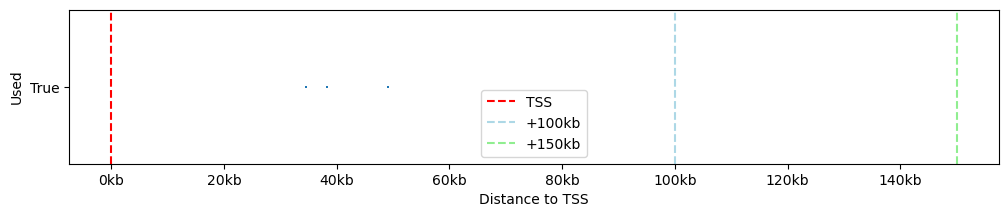

In [ ]:
fig, ax = plt.subplots(figsize=(12, 2))
sns.stripplot(data=enhancer_list_sample, x='distance_to_tss', y='used', ax=ax, jitter=False, size=1, marker='s', orient='h')
# vertical line at 0
ax.axvline(x=0, color='red', linestyle='--', label='TSS')
ax.axvline(x=100_000, color='lightblue', linestyle='--', label='+100kb')
ax.axvline(x=150_000, color='lightgreen', linestyle='--', label='+150kb')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: '{:,.0f}'.format(y/1000) + 'kb'))
ax.set_xlabel('Distance to TSS')
ax.set_ylabel('Used')
ax.legend()
plt.show()

In [ ]:
max_away = enhancer_list_sample[enhancer_list_sample['used'] == 1]['distance_to_tss'].max()
min_away = enhancer_list_sample[enhancer_list_sample['used'] == 1]['distance_to_tss'].min()
print(f'Max distance to TSS: {max_away}, Min distance to TSS: {min_away}')

Max distance to TSS: 49108.5, Min distance to TSS: 34603.5


# Apply the constraits fresh

In [ ]:
def filter_enhancers_by_distance(enhancer_start, tss, max_distance):
    distance = abs(enhancer_start - tss)
    return distance <= max_distance

def filter_enhancers_by_promoter(enhancer_start, tss):
    # enhancers around 2kb of the tss are considered promoters and thus excluded
    return abs(enhancer_start - tss) > 1000

In [ ]:
# go through enhancer_preds grouped by target gene and filter for regions by distance and promoter
# chr	start	end	name	TargetGene	TargetGeneTSS
if False:
    filtered_enhancers = []
    for target_gene, group in enhancer_preds.groupby('TargetGene'):
        tss = group['TargetGeneTSS'].values[0]
        group['distance'] = (group['start'] - tss).abs()
        group_sorted = group.sort_values(by='distance')
        n_enhancers = 0
        for _, row in group_sorted.iterrows():
            enhancer_start = row['start']
            if filter_enhancers_by_distance(enhancer_start, tss, 100_000) and filter_enhancers_by_promoter(enhancer_start, tss):
                filtered_tuple = (row['chr'], row['start'], row['end'], row['name'], target_gene, tss)
                filtered_enhancers.append(filtered_tuple)
                n_enhancers += 1
            if n_enhancers >= 60:
                break

    filtered_enhancers_df = pd.DataFrame(filtered_enhancers, columns=['chr', 'start', 'end', 'name', 'TargetGene', 'TargetGeneTSS'])
    filtered_enhancers_df

In [ ]:
# merge filtered_enhancher_df with enhancer_list activity_base values (by name)
activity_enhancers_df = filtered_enhancers_df.merge(enhancer_list[['name', 'activity_base']], on='name', how='left')
activity_enhancers_df = activity_enhancers_df.rename(columns={'activity_base': 'original_activity'})
activity_enhancers_df

NameError: name 'filtered_enhancers_df' is not defined

<Axes: xlabel='n_enhancers', ylabel='Count'>

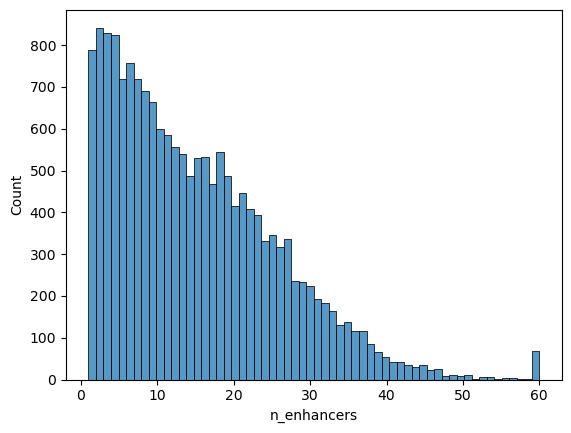

In [ ]:
# group by target gene and count how many enhancers are linked to it and histplot it
activity_enhancers_df['n_enhancers'] = activity_enhancers_df.groupby('TargetGene')['name'].transform('count')
# plot the distribution of n_enhancers per gene => ONLY COUNT EACH GENE ONCE
n_enhancers_per_gene = activity_enhancers_df.drop_duplicates(subset=['TargetGene'])['n_enhancers']
sns.histplot(n_enhancers_per_gene, bins=60)

## load our onwn

In [ ]:
k562_enhancer_links = pd.read_csv('../data/K562_gene_enhancer_links.csv')
k562_enhancer_links['region_len'] = k562_enhancer_links['end'] - k562_enhancer_links['start']
# sort by max
k562_enhancer_links = k562_enhancer_links.sort_values(by='region_len', ascending=False)
k562_enhancer_links

,chrom,start,end,name,gene_id,tss,region_len
11320,chr9,131025087,131032605,genic|chr9:131025087-131032605,ENSG00000050555,131009186,7518
250366,chr22,21051070,21057005,genic|chr22:21051070-21057005,ENSG00000184436,21001786,5935
36675,chr22,21051070,21057005,genic|chr22:21051070-21057005,ENSG00000099957,21015027,5935
36742,chr22,21051070,21057005,genic|chr22:21051070-21057005,ENSG00000099960,21032560,5935
261438,chr22,21051070,21057005,genic|chr22:21051070-21057005,ENSG00000187905,21045956,5935
...,...,...,...,...,...,...,...
93335,chr6,6315598,6316098,genic|chr6:6315598-6316098,ENSG00000124491,6320661,500
93391,chr6,34459873,34460373,intergenic|chr6:34459873-34460373,ENSG00000124507,34466075,500
93389,chr6,42549346,42549846,intergenic|chr6:42549346-42549846,ENSG00000124496,42451822,500
93386,chr6,42369479,42369979,genic|chr6:42369479-42369979,ENSG00000124496,42451822,500
